# Two bit Qmultiplier

In [49]:
def TwoBitQuantumMultiplier(number1 = None, number2 = None):

    from qiskit import QuantumCircuit
    from CircuitMakingFunctions import makeFullAdder, makeHalfAdder
    from qiskit.circuit import QuantumRegister, ClassicalRegister
    from qiskit.visualization import plot_histogram
    from qiskit.circuit.library import CCXGate, XGate, HGate, Reset, swap
    from qiskit.primitives import StatevectorSampler
    from IPython.display import display
    sampler = StatevectorSampler()


        #since these operations are from right to left, we iterate backwards:
        
    cr = ClassicalRegister(4,"classicalRegister")
    qr0 = QuantumRegister(1,"Control 1")
    qr1 = QuantumRegister(1,"A1")
    qr2 = QuantumRegister(1,"A2")
    qr3 = QuantumRegister(1,"B1")
    qr4 = QuantumRegister(1,"B2")
    qr5 = QuantumRegister(1,"Carry1")
    qr6 = QuantumRegister(1,"Prod1")
    qr7 = QuantumRegister(1,"Prod2")
    qr8 = QuantumRegister(1,"Prod3")
    qr9 = QuantumRegister(1,"Prod4")
    qr10 = QuantumRegister(1,"Temp1")
    qr11 = QuantumRegister(1,"Temp2")
    # qr23 = QuantumRegister(1,"Two's carry")

    qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, qr9, qr10, qr11, cr, name='Full-adder circuit')

    control_1 = 0
    A1 = 1
    A2 = 2
    B1 = 3
    B2 = 4
    Carry1 = 5
    Prod1 = 6
    Prod2 = 7
    Prod3 = 8
    Prod4 = 9
    Temp1 = 10
    Temp2 = 11

    if(number1 != None and number2 != None):
        if((number1 < 0 or number1 > 15 or number2 < 0 or number2 > 15)):
            print("Input Error. Inputs must be greater than or equal to 0 and less than or equal to 15")
            return False
        binary1 = bin(number1)[2:]
        binary2 = bin(number2)[2:]
        count = 1
        if(len(binary1) != 2):
            length = 2 - len(binary1)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary1 = buff + binary1
        if(len(binary2) != 2):
            length = 2 - len(binary2)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary2 = buff + binary2
        print(f"first operand {binary1} and second operand {binary2}\n")
    
    #read the input and set the 
    #appropiate qbits to |1>
        for x in range(2):
            if(binary1[x] == "1"):
                qc.append(XGate(), [count])
            count += 1

        count = 3
        for x in range(2):
            if(binary2[x] == "1"):
                qc.append(XGate(), [count])
            count += 1
    else:
        count = 1
        for x in range(2):
            qc.append(HGate(), [count])
            count += 1

        count = 3
        for x in range(2):
            qc.append(HGate(), [count])
            count += 1

    #set the control bit to |1>
    qc.append(XGate(), [control_1])
    #half adder args:     control_1 = 0
    # A = 1
    # B = 2
    # Sum = 3
    # Carry = 4

    #First, and between A2 and B2 for Prod1

    half_adder = makeHalfAdder()
    #Calc the 4th bit by doing A2 AND B2
    qc.append(CCXGate(), [A2, B2, Prod4])

    #Prod3 is the result sum of the half adder whos inputs are: A1 AND B2, and A2 AND B2
        #B2 AND A1 makes the A for the first half adder
    qc.append(CCXGate(), [A1, B2, Temp1])
        #B1 AND A2 makes the B for the first half adder
    qc.append(CCXGate(), [A2, B1, Temp2])

    # Half adder(control = control 1, A = Temp1, B = Temp 2, S = Prod 3, carry = Carry1)
    qc.append(half_adder, [control_1, Temp1, Temp2, Prod3, Carry1])

    #Clean the temp registers
            #undo B1 AND A2 
    qc.append(CCXGate(), [A2, B1, Temp2])

            #undo B2 AND A1 
    qc.append(CCXGate(), [A1, B2, Temp1])

    #Now, do A1 and B1 for the last half-adder's B (A is carry 1)
    qc.append(CCXGate(), [A1, B1, Temp1])

    qc.append(half_adder, [control_1, Temp1, Carry1, Prod2, Prod1 ])

    #clean temp 1
    qc.append(CCXGate(), [A1, B1, Temp1])

    # #now we can meassure the prods

    qc.measure(Prod4, 0)
    qc.measure(Prod3, 1)
    qc.measure(Prod2, 2)
    qc.measure(Prod1, 3)
    

   #COMMENT THIS MARKED SECTION WHEN USING THE TESTS AND METRICS FUNCTION --------------------------------------
    display(qc.draw("mpl"))
    samplerSim = StatevectorSampler()
    result = samplerSim.run([qc], shots=(1024*4)).result()
    counts = result[0].data.classicalRegister.get_counts()
    pretty_counts = {}
    # res = 0
    for bitstring, count in counts.items():
        prod_bits = bitstring

        label = f"product bits={prod_bits}, Product={int(bitstring,2)}"
        pretty_counts[label] = count
        if(number1 != None and number2 != None):
                print(bitstring, "→",
                    "prod bits =", bitstring,
                    "Result =", int(bitstring, 2),"\n")
                # res = int(bitstring, 2)
        res = bitstring
    # if(carry == "0"):
    #     print("we need two's comp.")

    # display(plot_histogram(pretty_counts, title="multiplier"))
   #-----------------------------------------------------------------------------------------------





    return qc

first operand 01 and second operand 01



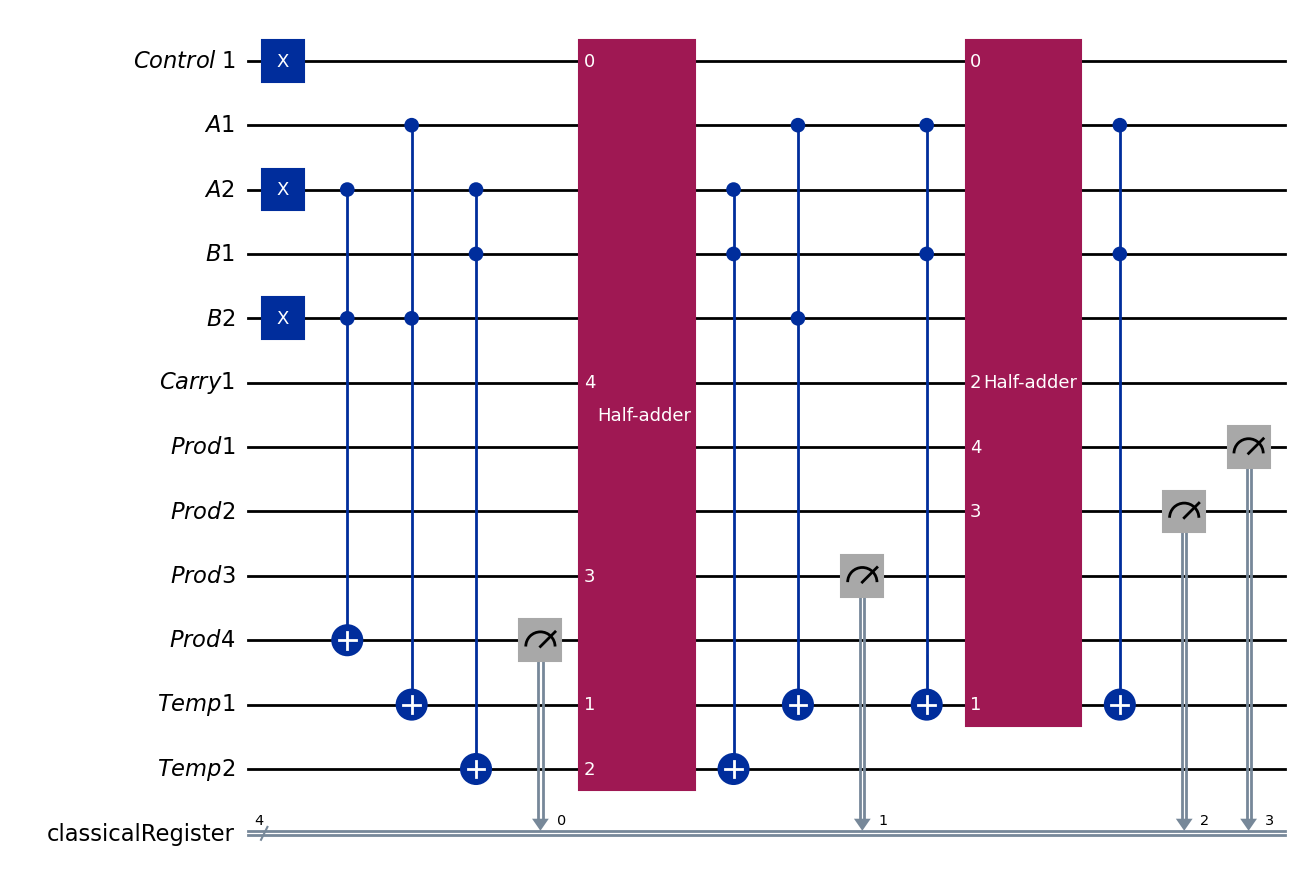

0001 → prod bits = 0001 Result = 1 

first operand 01 and second operand 01



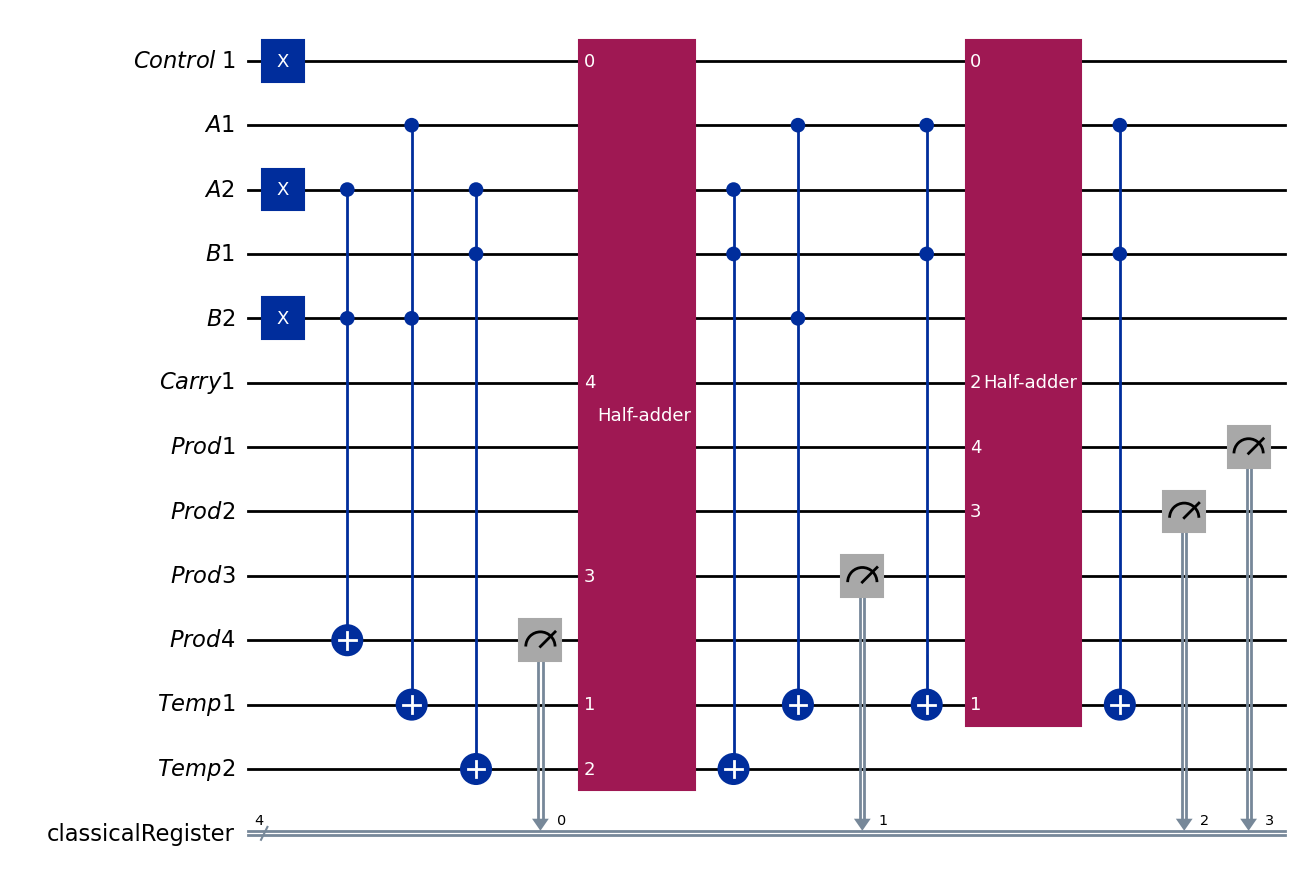

0001 → prod bits = 0001 Result = 1 



In [61]:
TwoBitQMult = TwoBitQuantumMultiplier(1,1)
TwoBitQMult = TwoBitQuantumMultiplier(1,1)

In [10]:
bin(2)

'0b10'